<h4>Setup</h4>

In [1]:
import QuantLib as ql

In [2]:
ql.Settings.instance().evaluationDate = ql.Date(3, ql.October, 2014)

<b>Specifying the reference date of a term structure</b>

In [3]:
helpers = [ ql.SwapRateHelper(ql.QuoteHandle(ql.SimpleQuote(rate/100.0)),
                              ql.Period(*tenor), ql.TARGET(),
                              ql.Annual, ql.Unadjusted,
                              ql.Thirty360(ql.Thirty360.BondBasis),
                              ql.Euribor6M())
            for tenor, rate in [((2,ql.Years), 0.201),
                                ((3,ql.Years), 0.258),
                                ((5,ql.Years), 0.464),
                                ((10,ql.Years), 1.151),
                                ((15,ql.Years), 1.588)] ]

In [4]:
curve1 = ql.PiecewiseFlatForward(0, ql.TARGET(), helpers, ql.Actual360())

In [5]:
dates, rates = zip(*curve1.nodes())

In [6]:
curve1.nodes()

((Date(3,10,2014), 0.0019777694879293093),
 (Date(7,10,2016), 0.0019777694879293093),
 (Date(9,10,2017), 0.0036475517704509294),
 (Date(7,10,2019), 0.007660760701876805),
 (Date(7,10,2024), 0.018414773669420893),
 (Date(8,10,2029), 0.025311634328221498))

The curve built based on these data will be the same as the first, except that we’re specifying its
reference date explicitly as October 3rd (the first passed date).

In [7]:
curve2 = ql.ForwardCurve(dates, rates, ql.Actual360())

Both curves are defined over the same range of dates...

In [8]:
print("{0} to {1}".format(curve1.referenceDate(), curve1.maxDate()))
print("{0} to {1}".format(curve2.referenceDate(), curve2.maxDate()))

October 3rd, 2014 to October 8th, 2029
October 3rd, 2014 to October 8th, 2029


...and return the same rates, whether we ask for a given time (for instance, 5 years)...

In [9]:
print(curve1.zeroRate(5.0, ql.Continuous))
print(curve2.zeroRate(5.0, ql.Continuous))

0.452196 % Actual/360 continuous compounding
0.452196 % Actual/360 continuous compounding


...or for a given date.

In [10]:
print(curve1.zeroRate(ql.Date(7, ql.September, 2019),
                      ql.Actual360(), ql.Continuous))
print(curve2.zeroRate(ql.Date(7, ql.September, 2019),
                      ql.Actual360(), ql.Continuous))
      

0.452196 % Actual/360 continuous compounding
0.452196 % Actual/360 continuous compounding


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

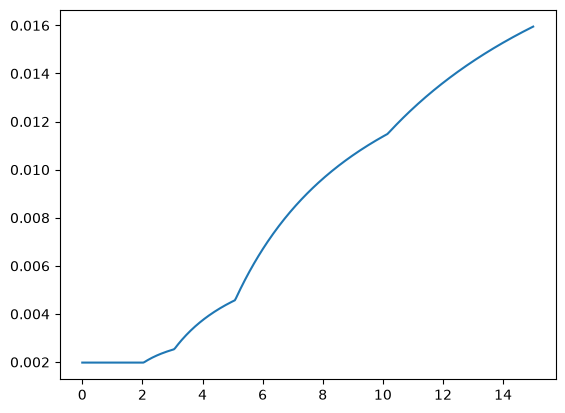

In [12]:
times = np.linspace(0.0, 15.0, 400)
rates = [curve1.zeroRate(t, ql.Continuous).rate() for t in times]
plt.plot(times, rates)
plt.show()

<h4>Moving the evaluation date</h4>

In [13]:
ql.Settings.instance().evaluationDate=ql.Date(19, ql.September, 2014)

As you might expect, the reference date of the first curve changes accordingly while that of the
second curve doesn’t. We can see how the range of definition has now changed for the first curve, but not for the second:

In [14]:
print("{0} to {1}".format(curve1.referenceDate(), curve1.maxDate()))
print("{0} to {1}".format(curve2.referenceDate(), curve2.maxDate()))

September 19th, 2014 to September 24th, 2029
October 3rd, 2014 to October 8th, 2029


And of course the rates have changed, too...

In [15]:
print(curve1.zeroRate(5.0, ql.Continuous))
print(curve2.zeroRate(5.0, ql.Continuous))
      

0.452196 % Actual/360 continuous compounding
0.452196 % Actual/360 continuous compounding


...if we look at them in the right way. The whole curve has moved back a couple of weeks, so if we
ask for a given time we’ll get the same rates; in other words, we’re asking for the zero rate over five years after the reference date, and that remains the same for a rigid translation of the curve. If we ask for the zero rate at a given date, though, we’ll see the effect:

In [16]:
print(curve1.zeroRate(ql.Date(7, ql.September, 2019),
                     ql.Actual360(), ql.Continuous))
print(curve2.zeroRate(ql.Date(7, ql.September, 2019),
                     ql.Actual360(), ql.Continuous))

0.454618 % Actual/360 continuous compounding
0.452196 % Actual/360 continuous compounding


<h4>Notifications</h4>

Finally, we can see how the two curves behave differently also with respect to notifications. Let’s
make two observers...

...and check that they work correctly by connecting them to a few quotes. The first observer will
receive notifications from the first and third quote, and the second observer will receive notifications from the second and third quote.

In [17]:
q1 = ql.SimpleQuote(1.0)
obs1.registerWith(q1)
q2 = ql.SimpleQuote(2.0)
obs2.registerWith(q2)
q3 = ql.SimpleQuote(3.0)
obs1.registerWith(q3)
obs2.registerWith(q3)

NameError: name 'obs1' is not defined